# Automatic Modulation Classification — Panoradio HF

Same SVM pipeline as the RadioML notebook, but trained on the **Panoradio HF** dataset:
18 real HF signal classes (AM, SSB, RTTY, PSK, Olivia, MT63, etc.), 6 kHz sample rate,
Watterson ionospheric fading channel. Real-world validation on a KiwiSDR AM broadcast recording.

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from scipy.stats import kurtosis
from tqdm.notebook import tqdm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Feature Extraction

Same 10 DSP-grounded features extracted per frame.

| Feature | Formula | Why it matters |
|---------|---------|----------------|
| Amplitude variance | $\text{Var}(x[n])$ | AM envelope varies; FSK/PSK constant |
| Amplitude kurtosis | $\text{Kurt}(x[n])$ | Peaky for tonal signals, flat for wideband |
| Phase variance | $\text{Var}(\Delta\phi[n])$ | PSK has discrete phase jumps; AM smooth |
| Freq variance | $\text{Var}(\Delta^2\phi[n])$ | FSK has high instantaneous freq deviation |
| Freq kurtosis | $\text{Kurt}(\Delta^2\phi[n])$ | Impulsive for keyed modes (RTTY, Morse) |
| Spectral symmetry | Upper/lower half power ratio | AM/USB/LSB differ strongly here |
| Spectral peak ratio | Peak / mean power | AM carrier gives sharp spectral spike |
| Spectral entropy | $-\sum p_k \log p_k$ | Low for narrowband, high for spread modes |
| Zero-crossing rate | Sign changes / N | Keyed modes (Morse, RTTY) pulse on/off |
| BW90 | Fraction of bins holding 90% power | Narrow for PSK31, wide for MT63/Olivia |

In [1]:
def extract_features(iq: np.ndarray) -> np.ndarray:
    """Extract 10 DSP-grounded features from a complex IQ array."""
    iq = iq.astype(np.complex64)

    amplitude = np.abs(iq)
    phase = np.unwrap(np.angle(iq))
    inst_freq = np.diff(phase)
    spectrum = np.abs(np.fft.fft(iq)) ** 2
    n = len(spectrum)

    amp_var      = np.var(amplitude)
    amp_kurt     = kurtosis(amplitude)
    phase_var    = np.var(np.diff(phase))
    freq_var     = np.var(inst_freq)
    freq_kurt    = kurtosis(inst_freq)
    sym          = np.sum(spectrum[1:n//2]) / (np.sum(spectrum[n//2:]) + 1e-12)
    peak_ratio   = np.max(spectrum) / (np.mean(spectrum) + 1e-12)
    spec_entropy = -np.sum((spectrum / spectrum.sum()) * np.log(spectrum / spectrum.sum() + 1e-12))

    # Zero-crossing rate: how often signal crosses zero (keyed modes pulse on/off)
    zcr = np.sum(np.diff(np.sign(iq.real)) != 0) / len(iq)

    # 90% power bandwidth: how wide the signal is in frequency
    spec_sorted = np.sort(spectrum)[::-1]
    cumpower = np.cumsum(spec_sorted)
    bw90 = np.searchsorted(cumpower, 0.9 * cumpower[-1]) / n

    return np.array([amp_var, amp_kurt, phase_var, freq_var, freq_kurt,
                     sym, peak_ratio, spec_entropy, zcr, bw90])

feature_names = [
    'Amp Variance', 'Amp Kurtosis', 'Phase Variance',
    'Freq Variance', 'Freq Kurtosis', 'Spectral Symmetry',
    'Peak Ratio', 'Spectral Entropy', 'Zero-Crossing Rate', 'BW90'
]

print('Feature vector for random complex signal:')
print(extract_features(np.random.randn(2048) + 1j * np.random.randn(2048)))

Feature vector for random complex signal:


NameError: name 'np' is not defined

## 2. Load Panoradio HF Dataset

In [16]:
PANORADIO_PATH = '../data/dataset_panoradio_hf.npy'
TAGS_PATH = '../data/dataset_panoradio_hf_tags.csv'

print("Loading dataset...", end=" ", flush=True)
X_raw = np.load(PANORADIO_PATH).astype(np.complex64)
tags = np.genfromtxt(TAGS_PATH, delimiter=',', dtype=str, skip_header=1)
y_raw = tags[:, 1].astype(str)
snr_raw = tags[:, 2].astype(float)

mods = sorted(set(y_raw))
snrs = sorted(set(snr_raw))
print("done")

print(f'Classes ({len(mods)}): {mods}')
print(f'SNR levels: {snrs}')
print(f'Total frames: {X_raw.shape[0]}  IQ samples per frame: {X_raw.shape[1]}')

Loading dataset... done
Classes (18): [np.str_('am'), np.str_('dominoex11'), np.str_('fax'), np.str_('lsb'), np.str_('morse'), np.str_('mt63_1000'), np.str_('navtex'), np.str_('olivia16_1000'), np.str_('olivia16_500'), np.str_('olivia32_1000'), np.str_('olivia8_250'), np.str_('psk31'), np.str_('psk63'), np.str_('qpsk31'), np.str_('rtty100_850'), np.str_('rtty45_170'), np.str_('rtty50_170'), np.str_('usb')]
SNR levels: [np.float64(-10.0), np.float64(-5.0), np.float64(0.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(25.0)]
Total frames: 172800  IQ samples per frame: 2048


## 3. Extract Features from All Frames

In [17]:
X, y, snr_labels = [], [], []

for iq_frame, label, snr in tqdm(zip(X_raw, y_raw, snr_raw), total=len(y_raw), desc="Extracting features"):
    X.append(extract_features(iq_frame))
    y.append(label)
    snr_labels.append(snr)

X = np.array(X)
y = np.array(y)
snr_labels = np.array(snr_labels, dtype=float)

print(f"Feature matrix: {X.shape}  ({X.shape[0]} samples, {X.shape[1]} features)")
print(f"Classes: {np.unique(y)}")

Extracting features:   0%|          | 0/172800 [00:00<?, ?it/s]

Feature matrix: (172800, 10)  (172800 samples, 10 features)
Classes: ['am' 'dominoex11' 'fax' 'lsb' 'morse' 'mt63_1000' 'navtex'
 'olivia16_1000' 'olivia16_500' 'olivia32_1000' 'olivia8_250' 'psk31'
 'psk63' 'qpsk31' 'rtty100_850' 'rtty45_170' 'rtty50_170' 'usb']


## 3.1 Feature Distributions per Class

Violin plots of each feature across all 18 HF signal classes at SNR ≥ 10 dB.

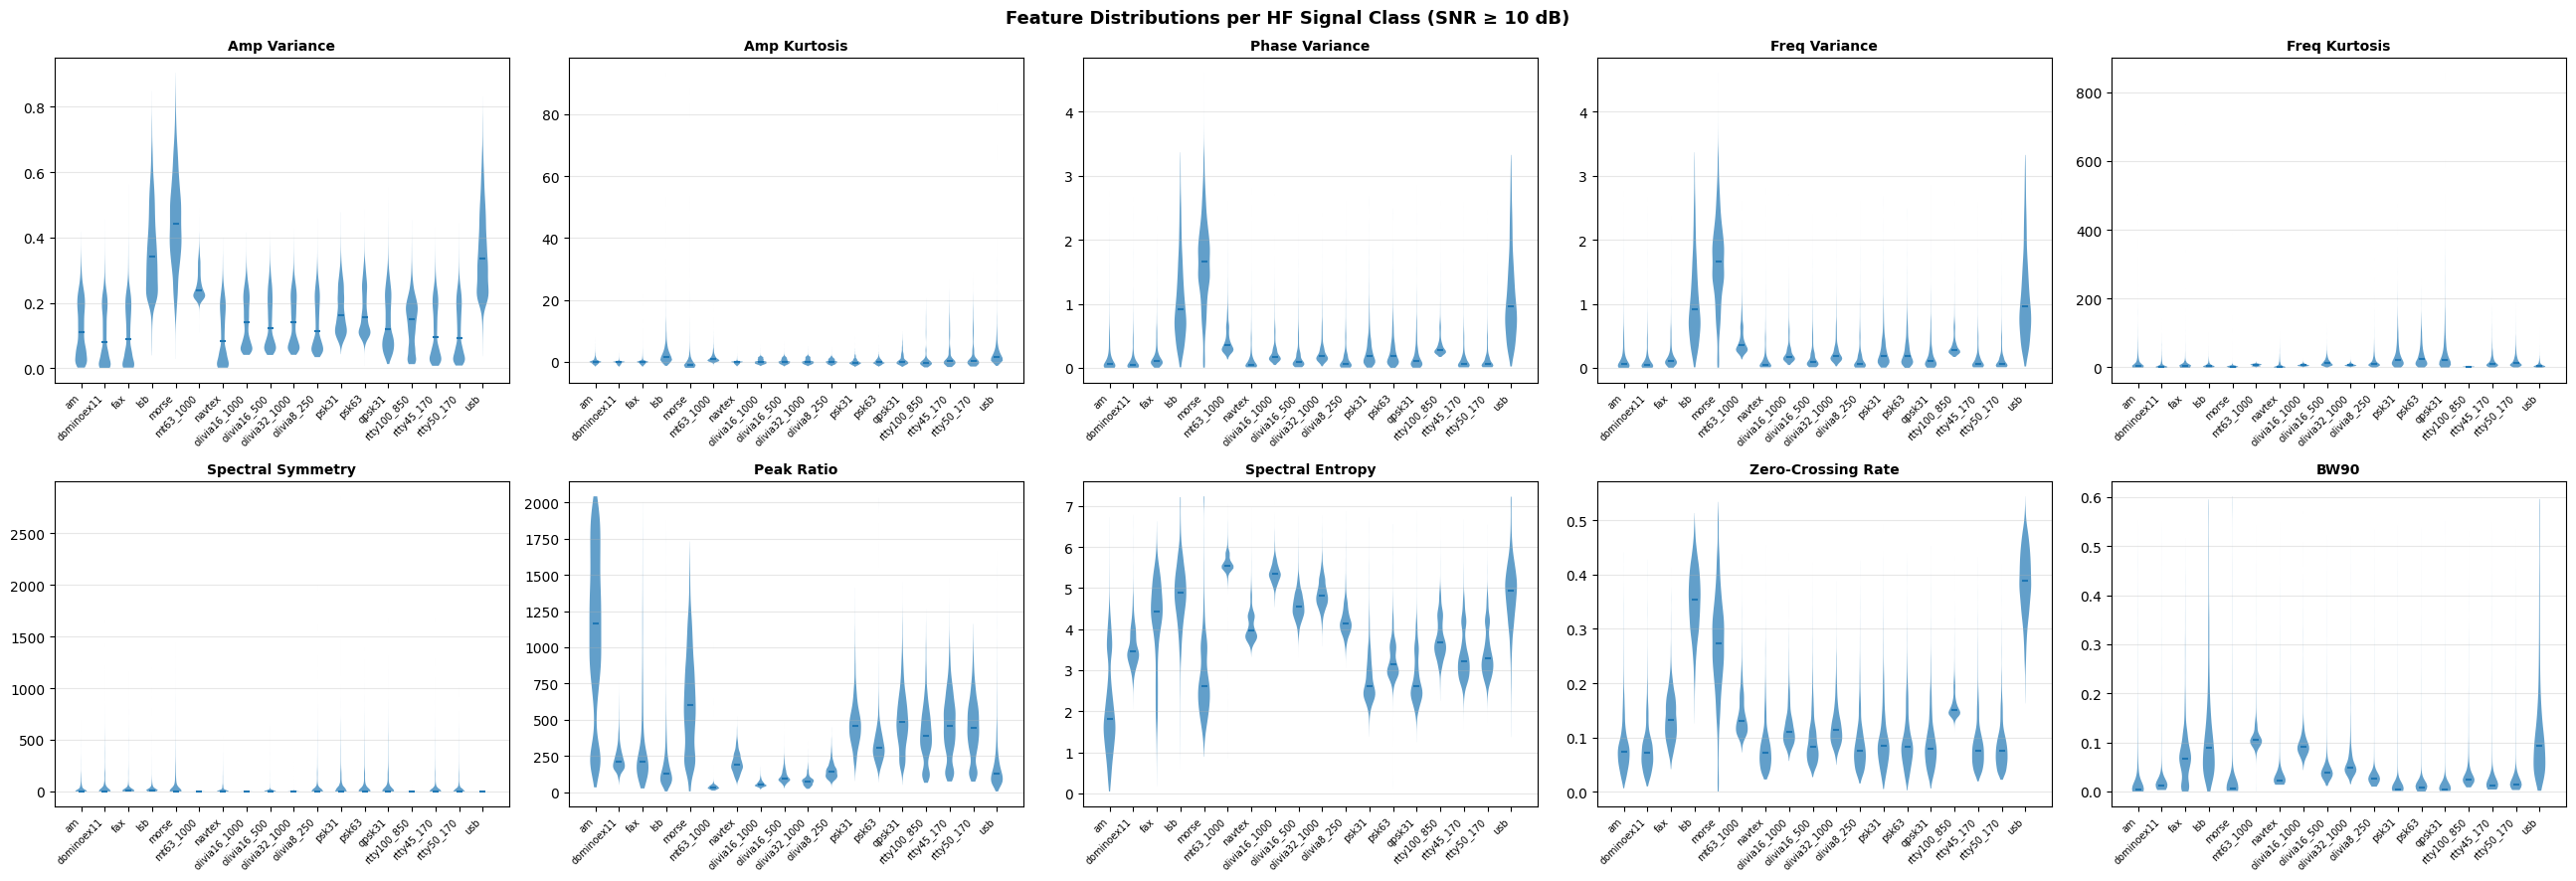

In [18]:
vis_mask = snr_labels >= 10
X_vis = X[vis_mask]
y_vis = y[vis_mask]

fig, axes = plt.subplots(2, 5, figsize=(26, 9))
axes = axes.flatten()

for feat_idx, (ax, fname) in enumerate(zip(axes, feature_names)):
    data_per_class = [X_vis[y_vis == mod, feat_idx] for mod in mods]
    parts = ax.violinplot(data_per_class, positions=range(len(mods)), showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(mods)))
    ax.set_xticklabels(mods, rotation=45, ha='right', fontsize=7)
    ax.set_title(fname, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Distributions per HF Signal Class (SNR ≥ 10 dB)', fontsize=13, fontweight='bold')
plt.tight_layout()

## 3.2 Merge Confusable Classes

Classes that differ only in baud rate or protocol framing — indistinguishable from instantaneous signal features — are merged into single labels. Reduces 18 → 10 classes:

- **rtty45/50/100** → `rtty` (differ only in baud rate)
- **olivia 8/16/32 variants** → `olivia` (same MFSK structure, different parameters)
- **psk31/psk63/qpsk31** → `psk` (differ only in constellation order, not signal statistics)

In [24]:
# Merge RTTY and Olivia variants
merge_map = {
    'psk31':        'psk',
    'psk63':        'psk',
    'qpsk31':       'psk',
    'rtty45_170':   'rtty',
    'rtty50_170':   'rtty',
    'rtty100_850':  'rtty',
    'olivia8_250':  'olivia',
    'olivia16_500': 'olivia',
    'olivia16_1000':'olivia',
    'olivia32_1000':'olivia',
}
y = np.array([merge_map.get(label, label) for label in y])
mods = sorted(set(y))
print(f"Classes after merge ({len(mods)}): {mods}")

Classes after merge (11): [np.str_('am'), np.str_('dominoex11'), np.str_('fax'), np.str_('lsb'), np.str_('morse'), np.str_('mt63_1000'), np.str_('navtex'), np.str_('olivia'), np.str_('psk'), np.str_('rtty'), np.str_('usb')]


## 4. Train / Val / Test Split and SVM Training

Train on SNR ≥ 0 dB only. 3-way split: 60% train / 20% val / 20% test.

In [25]:
import time

# Train on all SNR levels
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)
print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr'))
])

print("Training SVM...", end=" ", flush=True)
_t0 = time.time()
clf.fit(X_train, y_train)
print(f"done in {time.time() - _t0:.1f}s")

val_acc = accuracy_score(y_val, clf.predict(X_val))
print(f'Validation accuracy (all SNRs): {val_acc:.3f}')

Train: 103680  Val: 34560  Test: 34560
Training SVM... done in 64.6s
Validation accuracy (all SNRs): 0.757


## 5. Accuracy vs. SNR

In [ ]:
# ── Evaluate accuracy at each SNR level ──────────────────────────────────────
accs = []
for snr in tqdm(snrs, desc="Evaluating SNR levels"):
    mask = snr_labels == snr
    if mask.sum() == 0:
        accs.append(np.nan)
        continue
    accs.append(accuracy_score(y[mask], clf.predict(X[mask])))

# ── Visualization ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(snrs, accs, 'o-', linewidth=2, markersize=6)
plt.axhline(1/len(mods), color='gray', linestyle='--', label=f'Random chance ({1/len(mods):.2f})')
plt.axvline(0, color='red', linestyle=':', alpha=0.5, label='SNR = 0 dB')
plt.xlabel('SNR (dB)')
plt.ylabel('Classification Accuracy')
plt.title('SVM Modulation Classification Accuracy vs. SNR — Panoradio HF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()

## 6. Confusion Matrix

In [ ]:
# ── Compute confusion matrix (high SNR only, normalized) ─────────────────────
high_snr_mask = snr_labels >= 10
y_true = y[high_snr_mask]
y_pred = clf.predict(X[high_snr_mask])
cm = confusion_matrix(y_true, y_pred, labels=mods, normalize="true")

# ── Visualization ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mods)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix (SNR ≥ 10 dB) — Panoradio HF')
plt.tight_layout()

### Confusion Matrix Analysis

The normalized confusion matrix (SNR ≥ 10 dB) reveals clear structure in classifier performance across the 10 signal classes.

**Well-separated classes** achieve recall above 85%: USB (97%), Morse (96%), MT63 (96%), LSB (95%), PSK (95%), Olivia (93%), RTTY (86%), and AM (83%). These classes have distinctive spectral or temporal signatures that the 10 DSP features capture reliably — USB and LSB differ in spectral symmetry, Morse has a characteristic on/off keying pattern visible in zero-crossing rate, and MT63's wideband multicarrier structure produces high spectral entropy.

**Fax (73%) and DominoEx (68%)** are the weakest individual classes. Fax is confused primarily with Olivia (14%) due to its periodic multicarrier structure producing similar spectral entropy and bandwidth. DominoEx, a hybrid incremental-frequency MFSK mode, spreads its confusions across RTTY (12%) and PSK (10%), reflecting its mixed spectral characteristics.

**Navtex (59%)** is the hardest class — 32% of samples are misclassified as Olivia. Both are MFSK-based HF digital modes with nearly identical spectral profiles; the difference lies in protocol framing and baud rate rather than signal statistics, which are beyond the reach of instantaneous feature extraction.

**PSK merging** (psk31 + psk63 + qpsk31 → psk) improved PSK recall from ~56–82% per variant to 95% combined, confirming that the variants are spectrally indistinguishable at the feature level and are better treated as a single class.

## 7. Feature Space Visualization (3D)

Random Forest ranks the 8 features by importance. Two 3D scatter plots — top-3 and next-3 features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── Feature importance ranking via Random Forest ──────────────────────────────
print("Ranking features...", end=" ", flush=True)
_t = time.time()
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"done in {time.time()-_t:.1f}s")

importances = rf.feature_importances_
ranked = np.argsort(importances)[::-1]

print("\nFeature importance ranking:")
for r in ranked:
    print(f"  {feature_names[r]:20s}: {importances[r]:.4f}")

# ── Scale features and select high-SNR samples for visualization ──────────────
vis_mask = snr_labels >= 10
scaler = clf.named_steps['scaler']
X_scaled = scaler.transform(X[vis_mask])
y_vis = y[vis_mask]

colors = plt.cm.tab20(np.linspace(0, 1, len(mods)))
color_map = {mod: colors[i] for i, mod in enumerate(mods)}

# ── Visualization — 3D scatter (top-3 and next-3 features) ───────────────────
fig = plt.figure(figsize=(20, 9))
for plot_idx, feat_trio in enumerate([ranked[:3], ranked[3:6]]):
    ax = fig.add_subplot(1, 2, plot_idx + 1, projection='3d')
    f0, f1, f2 = feat_trio
    for mod in mods:
        mask = y_vis == mod
        ax.scatter(X_scaled[mask, f0], X_scaled[mask, f1], X_scaled[mask, f2],
                   label=mod, alpha=0.3, s=5, color=color_map[mod])
    ax.set_xlabel(feature_names[f0], fontsize=9, labelpad=8)
    ax.set_ylabel(feature_names[f1], fontsize=9, labelpad=8)
    ax.set_zlabel(feature_names[f2], fontsize=9, labelpad=8)
    ax.set_title(f"Top features {plot_idx*3+1}–{plot_idx*3+3}\n"
                 f"{feature_names[f0]}, {feature_names[f1]}, {feature_names[f2]}",
                 fontsize=10, fontweight='bold')

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=color_map[m], markersize=8, label=m) for m in mods]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.suptitle('3D Feature Space — Panoradio HF (SNR ≥ 10 dB)', fontsize=13, fontweight='bold')
plt.tight_layout()

## 8. Final Test Evaluation

Held-out test set — never seen during training or validation.

In [29]:
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Final test accuracy (SNR >= 0 dB): {test_acc:.3f}")
print(f"Validation accuracy:               {val_acc:.3f}")
print(f"Random chance baseline:            {1/len(mods):.3f}")

print("\nPer-class accuracy (test set, SNR >= 0 dB):")
for mod in mods:
    mask = y_test == mod
    if mask.sum() == 0:
        continue
    acc = accuracy_score(y_test[mask], clf.predict(X_test[mask]))
    bar = '█' * int(acc * 20)
    print(f"  {mod:15s}: {acc:.3f} {bar}")

Final test accuracy (SNR >= 0 dB): 0.761
Validation accuracy:               0.757
Random chance baseline:            0.091

Per-class accuracy (test set, SNR >= 0 dB):
  am             : 0.730 ██████████████
  dominoex11     : 0.510 ██████████
  fax            : 0.480 █████████
  lsb            : 0.723 ██████████████
  morse          : 0.749 ██████████████
  mt63_1000      : 0.733 ██████████████
  navtex         : 0.397 ███████
  olivia         : 0.924 ██████████████████
  psk            : 0.836 ████████████████
  rtty           : 0.783 ███████████████
  usb            : 0.823 ████████████████


## 9. Real-World Validation: KiwiSDR AM Recording

The Panoradio HF dataset was generated at 6 kHz with a realistic HF channel model (Watterson fading).
KiwiSDR also operates in the HF band. Segment the AM recording into 2048-sample frames
(same length as Panoradio) and classify.

In [ ]:
from src.data_tools.data_loaders import load_kiwisdr_iq

# ── Load and segment KiwiSDR recording ───────────────────────────────────────
KIWI_PATH = '../data/am_153khz.wav'
data = load_kiwisdr_iq(KIWI_PATH, sample_rate=12000.0)
iq = data.iq

frame_size = 2048
n_frames = len(iq) // frame_size
frames = iq[:n_frames * frame_size].reshape(n_frames, frame_size)
print(f"KiwiSDR frames: {n_frames} x {frame_size} samples")

# ── Extract features and classify ────────────────────────────────────────────
feats = np.array([extract_features(f) for f in tqdm(frames, desc="Extracting features")])

print("Classifying...", end=" ", flush=True)
_t0 = time.time()
preds = clf.predict(feats)
print(f"done in {time.time()-_t0:.1f}s")

# ── Results ──────────────────────────────────────────────────────────────────
unique, counts = np.unique(preds, return_counts=True)
print('\nPrediction distribution across frames:')
for mod, count in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f'  {mod:15s}: {count:4d} frames ({100*count/n_frames:.1f}%)')
print(f'\nMajority vote prediction: {unique[np.argmax(counts)]}')